<h2 style="color:blue">Multi-Class Sentiment Analyzer with Error Analysis Using Basic NLP</h2>

Dataset Used : Twitter US Airline Sentiment

### Load dataset

In [41]:
import pandas as pd

df=pd.read_csv("../Datasets/airline_tweets_dataset.csv")

df.shape

(14640, 15)

In [4]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

In [5]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### Data Preprocessing

In [7]:
# Keep only the two columns relevant to sentiment classification
df = df[["text", "airline_sentiment"]].copy()

df = df.rename(columns={"airline_sentiment": "sentiment"})

In [8]:
df.head()

,text,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [10]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

### Data Cleaning

In [12]:
import re

def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove @mentions (e.g. @VirginAmerica)
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word (e.g. #delayed -> delayed)
    text = re.sub(r"#", "", text)

    # Remove anything that isn't a lowercase letter or space
    text = re.sub(r"[^a-z\s]", "", text)

    # Collapse multiple spaces into one
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)


In [13]:
df.head()

,text,sentiment,clean_text
0,@VirginAmerica What @dhepburn said.,neutral,what said
1,@VirginAmerica plus you've added commercials t...,positive,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,neutral,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,negative,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,negative,and its a really big bad thing about it


In [14]:
df.isnull().sum()

text          0
sentiment     0
clean_text    0
dtype: int64

In [16]:
empty_after_cleaning = (df["clean_text"].str.strip() == "").sum()
print("Rows that became empty after cleaning:", empty_after_cleaning)

Rows that became empty after cleaning: 0


In [17]:
print(df["sentiment"].unique())
print(df["sentiment"].value_counts())

<ArrowStringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str
sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


### Data Imbalance Visualisation

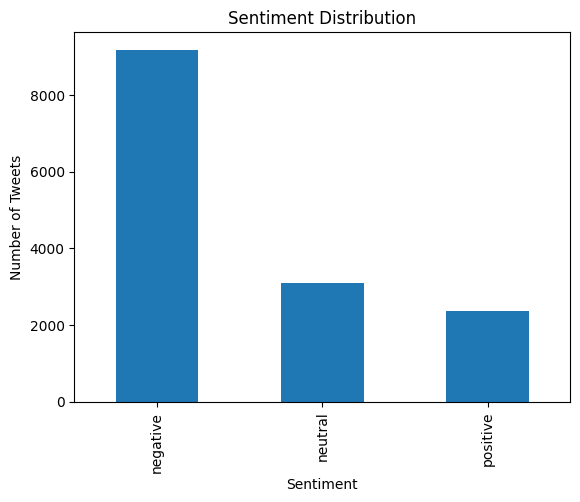

In [18]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 11712
Test size: 2928


### Tfidf Vectorization

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (11712, 5000)
Test shape: (2928, 5000)


### Model Training(Logistic Regression)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

#### Model Analysis

In [26]:
sample_predictions = model.predict(X_test_tfidf[:5])
print("Sample predictions:", sample_predictions)
print("Actual labels:     ", y_test[:5].tolist())

Sample predictions: ['negative' 'positive' 'negative' 'negative' 'negative']
Actual labels:      ['neutral', 'positive', 'negative', 'negative', 'negative']


In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7425

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.77      0.83      1835
     neutral       0.51      0.69      0.58       620
    positive       0.68      0.68      0.68       473

    accuracy                           0.74      2928
   macro avg       0.69      0.72      0.70      2928
weighted avg       0.77      0.74      0.75      2928



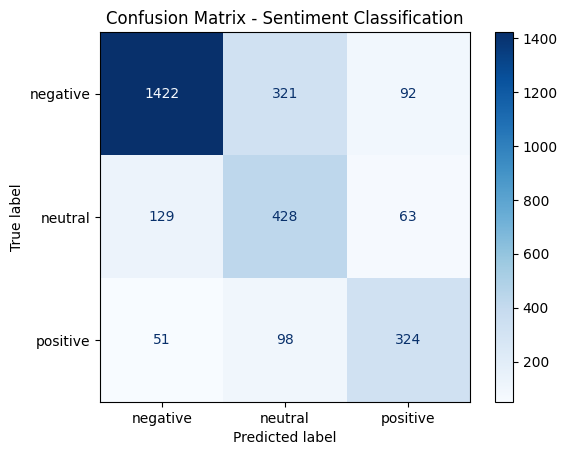

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Sentiment Classification")
plt.show()

### Error Analysis

In [31]:
import pandas as pd

# Build a results dataframe aligned with the test set
results_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

# Isolate only the wrong predictions
errors_df = results_df[results_df["actual"] != results_df["predicted"]]

print("Total test samples:", len(results_df))
print("Total errors:", len(errors_df))
print("Error rate:", round(len(errors_df) / len(results_df), 4))

errors_df.head(10)

Total test samples: 2928
Total errors: 754
Error rate: 0.2575


,text,actual,predicted
0,past,neutral,negative
9,when will the flight resume i dons see it in t...,negative,neutral
12,of course but they were just as helpless as ev...,negative,positive
14,no oscars on direct tv on this flight we were ...,negative,positive
15,why would i pay to reactivate my points that a...,negative,neutral
18,well i did miss it but gate agents had rebooke...,positive,negative
22,my flight was leaving las vegas at pm arriving...,negative,neutral
30,any site gmail facebook etc,neutral,negative
33,such a bummer but i understand its a business ...,neutral,negative
39,she was traveling with me the one that got mis...,negative,neutral


In [34]:
# Which sentiment gets confused with which, most often?
error_breakdown = errors_df.groupby(["actual", "predicted"]).size().sort_values(ascending=False)
print(error_breakdown)

actual    predicted
negative  neutral      321
neutral   negative     129
positive  neutral       98
negative  positive      92
neutral   positive      63
positive  negative      51
dtype: int64


In [37]:
# cases where actual=neutral but model predicted negative
mask = (errors_df["actual"] == "neutral") & (errors_df["predicted"] == "negative")
errors_df[mask]["text"].head(10)

0                                                   past
30                           any site gmail facebook etc
33     such a bummer but i understand its a business ...
55     i was under the impression when there is an ho...
70                         have five people shown up yet
209    can you tweet me the cancelled flightchng fee ...
228                                  using jetblue miles
232    unfortunately not i think i watched it take of...
242    there are significant number of folks on conne...
303                                  and gold status too
Name: text, dtype: str